## Config

In [ ]:
from pathlib import Path

# ================= 1. 專案根目錄 =================
ROOT = Path("/home/liang/workdir/NCKU-ML-25Fall/Final_Project")

# ================= 2. 原始資料來源 (Raw Source) =================
RAW_IMAGES_ROOT = ROOT / "images"           # 原始雜亂的圖片資料夾
RAW_COCO_JSON   = ROOT / "annotations" / "positive_3_labels.json"

# ================= 3. 標準化大圖資料集 (Standardized Full-Size Dataset) =================

DATASET_DIR   = ROOT / "dataset"
IMG_ALL_DIR   = DATASET_DIR / "images" / "all"       # 所有大圖彙整處
IMG_TRAIN_DIR = DATASET_DIR / "images" / "train"     # 訓練用大圖
IMG_VAL_DIR   = DATASET_DIR / "images" / "val"       # 驗證用大圖
IMG_UNLAB_DIR = DATASET_DIR / "images" / "unlabeled" # 未標註大圖
ANNOT_DIR     = DATASET_DIR / "annotations"          # 存放 instances_train.json / val.json

# ================= 4. 切圖後資料集 (Tiled Dataset for Training) =================
TILE_SIZE = 640
OVERLAP_RATIO = 0.2

DATASET_TILED_DIR = ROOT / f"dataset_tiled_{TILE_SIZE}"

# 切圖後的子目錄結構 (仿照 YOLO 格式)
IMG_TILED_TRAIN_DIR = DATASET_TILED_DIR / "images" / "train"
IMG_TILED_VAL_DIR   = DATASET_TILED_DIR / "images" / "val"
ANNOT_TILED_DIR     = DATASET_TILED_DIR / "annotations"

# 切圖後的新 JSON 檔案路徑
JSON_TILED_TRAIN = ANNOT_TILED_DIR / "instances_train_tiled.json"
JSON_TILED_VAL   = ANNOT_TILED_DIR / "instances_val_tiled.json"

# 自動產生的 YAML 路徑
YAML_TILED_PATH  = DATASET_TILED_DIR / "dataset_tiled.yaml"

In [6]:
# 3. 切圖參數設定
SLICE_HEIGHT = 640
SLICE_WIDTH = 640
OVERLAP_HEIGHT_RATIO = 0.2  # 20% 重疊
OVERLAP_WIDTH_RATIO = 0.2   # 20% 重疊

## Slicing

In [7]:
from sahi.slicing import slice_coco
import os
import shutil

def run_offline_slicing(source_img_dir, source_json_path, target_img_dir, target_ann_dir, target_json_name, split_name):
    print(f"正在處理 {split_name} 集切圖...")

    # 確保輸出目錄存在
    Path(target_img_dir).mkdir(parents=True, exist_ok=True)
    Path(target_ann_dir).mkdir(parents=True, exist_ok=True)

    # 使用 SAHI 的 slice_coco 核心功能
    # 這個函式會讀取 JSON 和圖片，進行切割，並輸出新的圖片和新的 JSON
    coco_dict, coco_path = slice_coco(
        coco_annotation_file_path=source_json_path,
        image_dir=source_img_dir,
        output_coco_annotation_file_name=target_json_name,
        output_dir=target_img_dir, # SAHI 會把圖片和 JSON 都輸出到這裡
        slice_height=SLICE_HEIGHT,
        slice_width=SLICE_WIDTH,
        overlap_height_ratio=OVERLAP_HEIGHT_RATIO,
        overlap_width_ratio=OVERLAP_WIDTH_RATIO,
        min_area_ratio=0.1, # 如果切下來的框框面積小於原框的 10%，則丟棄該框 (避免邊緣雜訊)
        verbose=1,
        ignore_negative_samples=False # 這裡建議設為 False，保留沒有病灶的背景圖，減少 False Positive
    )

    # SAHI 預設會把 json 輸出在 output_dir (圖片資料夾) 下，我們把它移動到標準的 annotations 資料夾
    generated_json_path = os.path.join(target_img_dir, target_json_name)
    
    # [修正] SAHI 有時候會自動在檔名後面加上 _coco.json，這裡做個檢查
    if not os.path.exists(generated_json_path):
        if os.path.exists(generated_json_path + "_coco.json"):
            generated_json_path += "_coco.json"

    final_json_path = os.path.join(target_ann_dir, target_json_name)
    shutil.move(generated_json_path, final_json_path)

    print(f"✅ {split_name} 集切圖完成！")
    print(f"   - 新圖片位置: {target_img_dir}")
    print(f"   - 新 Annotation 位置: {final_json_path}")
    # 簡單統計
    import json
    with open(final_json_path, 'r') as f:
        data = json.load(f)
    print(f"   - 原本圖片數量 (估計): {len(os.listdir(source_img_dir))}")
    print(f"   - 切圖後圖片數量: {len(data['images'])}")
    print(f"   - 切圖後標註數量: {len(data['annotations'])}")
    print("-" * 30)

In [8]:
import shutil

# 呼叫切圖函式 (Train Set)
run_offline_slicing(
    source_img_dir   = str(IMG_TRAIN_DIR),       # 讀取 dataset/images/train
    source_json_path = str(ANNOT_DIR / "instances_train.json"),
    target_img_dir   = str(IMG_TILED_TRAIN_DIR), # 輸出到 dataset_tiled_640/images/train
    target_ann_dir   = str(ANNOT_TILED_DIR),
    target_json_name = "instances_train_tiled.json",
    split_name       = "TRAIN"
)

# 呼叫切圖函式 (Val Set)
run_offline_slicing(
    source_img_dir   = str(IMG_VAL_DIR),         # 讀取 dataset/images/val
    source_json_path = str(ANNOT_DIR / "instances_val.json"),
    target_img_dir   = str(IMG_TILED_VAL_DIR),   # 輸出到 dataset_tiled_640/images/val
    target_ann_dir   = str(ANNOT_TILED_DIR),
    target_json_name = "instances_val_tiled.json",
    split_name       = "VAL"
)

正在處理 TRAIN 集切圖...


  0%|          | 0/24 [00:00<?, ?it/s]2025-12-11 17:27:03,968 - sahi - INFO - image.shape: (3840, 2160) (slicing.py:325)
2025-12-11 17:27:04,127 - sahi - INFO - Num slices: 32 slice_height: 640 slice_width: 640 (slicing.py:399)
  4%|▍         | 1/24 [00:00<00:08,  2.72it/s]2025-12-11 17:27:04,253 - sahi - INFO - sliced image path: /home/liang/workdir/NCKU-ML-25Fall/Final_Project/dataset_tiled_640/images/train/12_0_1536_0_2176_640.png (slicing.py:317)
2025-12-11 17:27:04,262 - sahi - INFO - sliced image path: /home/liang/workdir/NCKU-ML-25Fall/Final_Project/dataset_tiled_640/images/train/12_0_0_0_640_640.png (slicing.py:317)
2025-12-11 17:27:04,286 - sahi - INFO - sliced image path: /home/liang/workdir/NCKU-ML-25Fall/Final_Project/dataset_tiled_640/images/train/12_0_2048_0_2688_640.png (slicing.py:317)
2025-12-11 17:27:04,291 - sahi - INFO - sliced image path: /home/liang/workdir/NCKU-ML-25Fall/Final_Project/dataset_tiled_640/images/train/12_0_2560_0_3200_640.png (slicing.py:317)
2025-1

✅ TRAIN 集切圖完成！
   - 新圖片位置: /home/liang/workdir/NCKU-ML-25Fall/Final_Project/dataset_tiled_640/images/train
   - 新 Annotation 位置: /home/liang/workdir/NCKU-ML-25Fall/Final_Project/dataset_tiled_640/annotations/instances_train_tiled.json
   - 原本圖片數量 (估計): 27
   - 切圖後圖片數量: 768
   - 切圖後標註數量: 2075
------------------------------
正在處理 VAL 集切圖...


Loading coco annotations:   0%|          | 0/5 [00:00<?, ?it/s]2025-12-11 17:27:14,324 - sahi - INFO - sliced image path: /home/liang/workdir/NCKU-ML-25Fall/Final_Project/dataset_tiled_640/images/train/14_23_0_512_640_1152.png (slicing.py:317)
2025-12-11 17:27:14,335 - sahi - INFO - sliced image path: /home/liang/workdir/NCKU-ML-25Fall/Final_Project/dataset_tiled_640/images/train/14_23_1536_512_2176_1152.png (slicing.py:317)
2025-12-11 17:27:14,335 - sahi - INFO - sliced image path: /home/liang/workdir/NCKU-ML-25Fall/Final_Project/dataset_tiled_640/images/train/14_23_512_1024_1152_1664.png (slicing.py:317)
2025-12-11 17:27:14,335 - sahi - INFO - sliced image path: /home/liang/workdir/NCKU-ML-25Fall/Final_Project/dataset_tiled_640/images/train/14_23_0_1024_640_1664.png (slicing.py:317)
2025-12-11 17:27:14,348 - sahi - INFO - sliced image path: /home/liang/workdir/NCKU-ML-25Fall/Final_Project/dataset_tiled_640/images/train/14_23_2560_0_3200_640.png (slicing.py:317)
2025-12-11 17:27:14,35

✅ VAL 集切圖完成！
   - 新圖片位置: /home/liang/workdir/NCKU-ML-25Fall/Final_Project/dataset_tiled_640/images/val
   - 新 Annotation 位置: /home/liang/workdir/NCKU-ML-25Fall/Final_Project/dataset_tiled_640/annotations/instances_val_tiled.json
   - 原本圖片數量 (估計): 5
   - 切圖後圖片數量: 160
   - 切圖後標註數量: 410
------------------------------


大圖尺寸: 3840x2160
切片尺寸: 640x640
總共切出: 32 張小圖


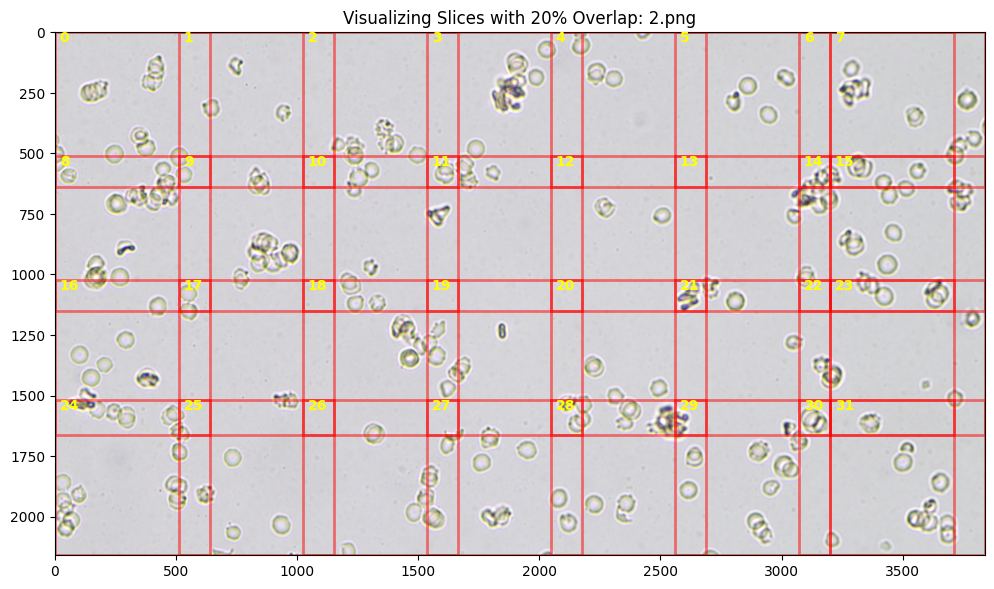

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import os
import random

# Config
SOURCE_IMAGES_DIR = IMG_TRAIN_DIR
SLICE_WIDTH = 640
SLICE_HEIGHT = 640
OVERLAP_WIDTH_RATIO = 0.2
OVERLAP_HEIGHT_RATIO = 0.2

# 隨機選一張大圖
image_files = [f for f in os.listdir(SOURCE_IMAGES_DIR) if f.endswith(('.png', '.jpg'))]
if not image_files:
    print("找不到原始圖片")
else:
    example_image_name = random.choice(image_files)
    example_image_path = os.path.join(SOURCE_IMAGES_DIR, example_image_name)

    img = Image.open(example_image_path)
    img_w, img_h = img.size

    # 計算切片視窗的起始點 (SAHI 內部邏輯的簡化版)
    step_w = int(SLICE_WIDTH * (1 - OVERLAP_WIDTH_RATIO))
    step_h = int(SLICE_HEIGHT * (1 - OVERLAP_HEIGHT_RATIO))

    x_starts = list(range(0, img_w - SLICE_WIDTH, step_w))
    if (img_w - SLICE_WIDTH) % step_w != 0: # 處理最後邊緣
        x_starts.append(img_w - SLICE_WIDTH)
        
    y_starts = list(range(0, img_h - SLICE_HEIGHT, step_h))
    if (img_h - SLICE_HEIGHT) % step_h != 0: # 處理最後邊緣
        y_starts.append(img_h - SLICE_HEIGHT)

    # 繪圖
    fig, ax = plt.subplots(figsize=(12, 12))
    ax.imshow(img)
    ax.set_title(f"Visualizing Slices with {int(OVERLAP_WIDTH_RATIO*100)}% Overlap: {example_image_name}")

    # 畫出每一個切片的框
    count = 0
    for y in y_starts:
        for x in x_starts:
            # 這裡的 x, y 是切片左上角在大圖中的座標
            # 使用半透明紅色框標示切片範圍
            rect = patches.Rectangle((x, y), SLICE_WIDTH, SLICE_HEIGHT, linewidth=2, edgecolor='r', facecolor='none', alpha=0.5)
            ax.add_patch(rect)
            # 在框的角落標上編號，方便對照
            ax.text(x+20, y+40, str(count), color='yellow', fontsize=10, fontweight='bold')
            count += 1

    print(f"大圖尺寸: {img_w}x{img_h}")
    print(f"切片尺寸: {SLICE_WIDTH}x{SLICE_HEIGHT}")
    print(f"總共切出: {count} 張小圖")
    plt.show()

## Train Yaml

In [ ]:
import yaml

yaml_content = {
    "path": str(DATASET_TILED_DIR.absolute()), # 使用絕對路徑最保險
    "train": "images/train",
    "val": "images/val",
    "names": {
        0: "Abnormal" # 根據你的 positive_3_labels.json 修改這裡的類別名稱
    }
}

# 寫入 YAML 檔案
with open(YAML_TILED_PATH, 'w') as f:
    yaml.dump(yaml_content, f, sort_keys=False)

print(f"✅ 訓練配置檔已建立: {YAML_TILED_PATH}")
print(f"內容預覽:\n{yaml_content}")

✅ 訓練配置檔已建立: /home/liang/workdir/NCKU-ML-25Fall/Final_Project/dataset_tiled_640/dataset_tiled.yaml
內容預覽:
{'path': '/home/liang/workdir/NCKU-ML-25Fall/Final_Project/dataset_tiled_640', 'train': 'images/train', 'val': 'images/val', 'names': {0: 'Abnormal'}}


## Train

In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt") 

results = model.train(
    data=str(YAML_TILED_PATH),
    imgsz=640,
    epochs=30,
    batch=16,
    project=str(ROOT / "runs/train"), # 指定訓練結果存檔路徑
    name="yolo11n_tiled_640",         # 實驗名稱
    exist_ok=True,                    # 若資料夾存在則覆蓋或累加
    patience=10,                      # 如果 10 epoch 沒進步就提早停止
    verbose=True
)

print("🎉 訓練完成！權重儲存於:", results.save_dir)

Ultralytics 8.3.235 🚀 Python-3.10.19 torch-2.9.1+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition, 97259MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/liang/workdir/NCKU-ML-25Fall/Final_Project/dataset_tiled_640/dataset_tiled.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolo11n_tiled_640, nbs=64, nms=False, 

正在對大圖進行推論: /home/liang/workdir/NCKU-ML-25Fall/Final_Project/dataset/images/val/13.png
Performing prediction on 32 slices.
推論完成，找到 36 個病灶。


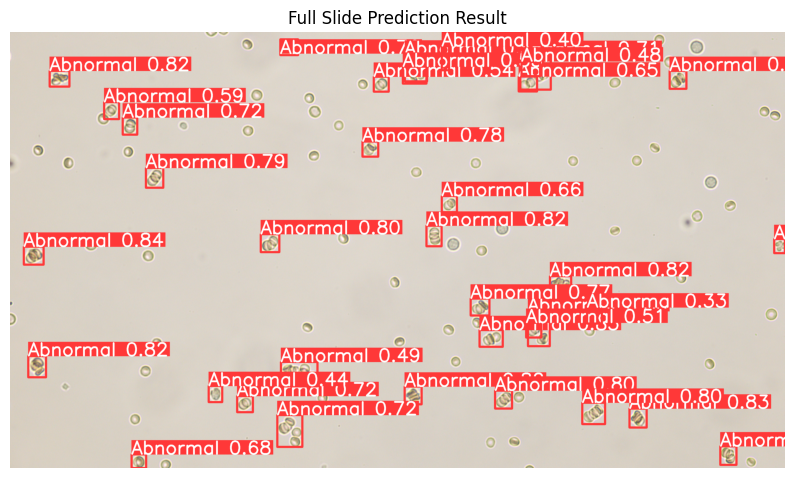

In [19]:
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
from sahi.utils.cv import visualize_object_predictions
import cv2
import matplotlib.pyplot as plt

# 1. 載入剛剛訓練好的最佳權重
best_model_path = str(ROOT / "runs/train/yolo11n_tiled_640/weights/best.pt")

# 設定 SAHI 模型介面
detection_model = AutoDetectionModel.from_pretrained(
    model_type='yolo11',
    model_path=best_model_path,
    confidence_threshold=0.25, # 信心度門檻
    device="cuda:0", # 或是 'cpu'
)

# 2. 挑選一張「原始大圖 (Validation Set)」來測試
# 注意：我們要讀的是 DATASET_DIR (未切圖) 裡的圖片
val_images = list(IMG_VAL_DIR.glob("*.png")) # 假設是 png
if val_images:
    test_image_path = str(val_images[2]) # 先拿第一張來試
    print(f"正在對大圖進行推論: {test_image_path}")

    # 3. 使用 SAHI 進行切片推論 (Slicing Inference)
    result = get_sliced_prediction(
        test_image_path,
        detection_model,
        slice_height=640,
        slice_width=640,
        overlap_height_ratio=0.2,
        overlap_width_ratio=0.2
    )

    # 4. 輸出與視覺化
    # 方式 A: 儲存預測結果圖
    output_vis_path = str(ROOT / "vis_result_full_slide.png")
    result.export_visuals(export_dir=str(ROOT), file_name="vis_result_full_slide")
    
    # 方式 B: 在 Notebook 顯示 (縮圖顯示以免太大)
    print(f"推論完成，找到 {len(result.object_prediction_list)} 個病灶。")
    
    # 簡單顯示縮圖
    img = cv2.imread(output_vis_path)
    plt.figure(figsize=(10, 10))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title("Full Slide Prediction Result")
    plt.show()

else:
    print("找不到驗證集圖片，請檢查 IMG_VAL_DIR")